In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_mean_rate(
    flux_file: str,
    dt_ps: float = 5.0,
    window_time: float = 5e-10,
):
    iterations, weights, pc1s = [], [], []
    with open(flux_file, "r") as f:
        for line in f:
            if not line.strip().startswith("Iteration"):
                continue
            try:
                parts = [p.strip() for p in line.split(",")]
                it = int(parts[0].split()[1])              # "Iteration 34" -> 34
                wt = float(parts[2].split(":")[1].strip()) # "Weight: ..." -> float
                pc1 = float(parts[3].split("=")[1].strip())# "pc1=..." -> float

                iterations.append(it)
                weights.append(wt)
                pc1s.append(pc1)
                # pc2s.append(pc2)
            except Exception as e:
                # Debugging help if format is unexpected
                print(f"Skipping line due to error: {line.strip()} ({e})")
                continue

    if not iterations:
        raise ValueError("No valid lines found in flux file")

    iterations = np.array(iterations)
    weights = np.array(weights)

    # --- Aggregate per iteration ---
    max_iter = iterations.max()
    flux = np.zeros(max_iter)

    for it in range(1, max_iter + 1):
        mask = (iterations == it)
        if it > 200:
            wts = weights[mask]
            #np.where(wts < 1e-5)
            if len(wts):
                #print(np.max(wts))
                #wts = wts[np.where(wts < 1.0e-3)[0]]

                flux[it - 1] = wts.sum() if np.any(mask) else 0.0
            else:
                flux[it -1] = 0.0

        else:
            flux[it - 1] = weights[mask].sum() if np.any(mask) else 0.0

    # --- Time scaling ---
    tau = dt_ps * 1e-12          # seconds per frame
    window_frames = int(window_time / tau)

    time_ns, rate = [], []
    for i in range(len(flux)):
        if i <= window_frames:
            flux_mean = np.mean(flux[:i+1])
        else:
            flux_mean = np.mean(flux[i-window_frames+1:i+1])

        time_ns.append((i+1) * tau * 1e9)     # ns
        rate.append(flux_mean / tau)          # 1/s

    return np.array(time_ns), np.array(rate)


def bayesian_bootstrap_mean_ci(values, n_boot=20000, ci=0.95, random_state=0):
    """
    Bayesian bootstrap for mean and credible interval.

    values: array-like, shape (n_samples,)
    """
    rng = np.random.default_rng(random_state)
    n = len(values)

    # Dirichlet weights
    weights = rng.dirichlet(np.ones(n), size=n_boot)

    # Posterior samples of the mean
    means = weights @ values

    mean_est = means.mean()
    alpha = (1 - ci) / 2
    lo, hi = np.quantile(means, [alpha, 1 - alpha])

    return mean_est, lo, hi


def mean_ci_from_replicas(t_ref, lts, lrs, npts=2500):
    """
    Interpolate replicas onto a common time grid and compute
    Bayesian bootstrap mean and CI.
    """
    t_common = t_ref[:npts]

    interp_vals = [
        np.interp(t_common, lt, lr) for lt, lr in zip(lts[1:], lrs[1:])
    ]

    mean = np.zeros_like(t_common)
    lo   = np.zeros_like(t_common)
    hi   = np.zeros_like(t_common)

    for i in range(len(t_common)):
        vals = np.array([lrs[0][i]] + [v[i] for v in interp_vals])
        m, l, h = bayesian_bootstrap_mean_ci(vals)
        mean[i], lo[i], hi[i] = m, l, h

    return t_common, mean, lo, hi

# ============================================================
# RATE COMPUTATION
# ============================================================

def compute_triplet(paths, **kwargs):
    return [compute_mean_rate(p, **kwargs) for p in paths]

## Dimension dependent rate (1D)

In [10]:
path = "./data/assets/Toy/flux_files/"

# Muted, self-contained plotting palette.
color_bruteforce_200 = "#B8AEA6"
color_bruteforce_50 = "#A8B7C7"
color_T_200k = "#9E3D3D"
color_T_50k = "#2F5D8A"
color_x_dim = "#2F5D8A"
color_xy_dim = "#4C7F7A"
c_bf = color_bruteforce_200
c_50k = color_T_50k
c_200k = color_T_200k
c_2d = color_xy_dim

x1 = path + "flux_file_x_1_0.1_T50.txt"
x2 = path + "flux_file_x_0.5_T50.txt"
x3 = path + "flux_file_x_1_0.5_T50.txt"
x4 = path + "flux_file_x_3_0.5_T50.txt"
x5 = path + "flux_file_x_1_0.5_T200.txt"
x6 = path + "flux_file_x_2_0.5_T200.txt"
x7 = path + "flux_file_x_3_0.5_T200.txt"
x8 = path + "flux_file_x_1_0.1_T200.txt"
x9 = path + "flux_file_x_2_0.1_T200.txt"
x10 = path + "flux_file_x_3_0.1_T200.txt"

x11 = path + "flux_file_xy_1_0.2_T200.txt"
x12 = path + "flux_file_xy_3_0.2_T50.txt"
x13 = path + "flux_file_xy_2_0.2_T50.txt"

# --- 50 K ---
lt7, lr7   = compute_mean_rate(x8,  dt_ps=0.1, window_time=5e-11)
lt8, lr8   = compute_mean_rate(x9,  dt_ps=0.1, window_time=5e-11)
lt9, lr9   = compute_mean_rate(x10, dt_ps=0.1, window_time=5e-11)

lt10, lr10 = compute_mean_rate(x11, dt_ps=0.2, window_time=1e-10)
lt11, lr11 = compute_mean_rate(x12, dt_ps=0.2, window_time=1e-10)
lt12, lr12 = compute_mean_rate(x13, dt_ps=0.2, window_time=1e-10)

# --- 200 K ---
lt4, lr4 = compute_mean_rate(x5, dt_ps=0.5, window_time=1e-10)
lt5, lr5 = compute_mean_rate(x6, dt_ps=0.5, window_time=1e-10)
lt6, lr6 = compute_mean_rate(x7, dt_ps=0.5, window_time=1e-10)

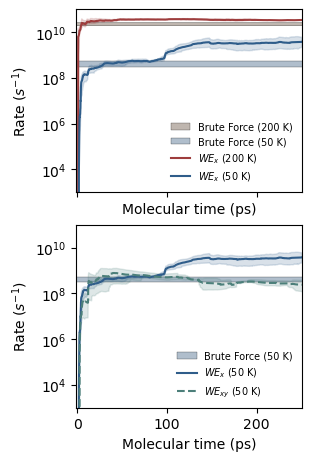

In [11]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.0, 4.5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# ============================================================
# TOP PANEL — Temperature dependence (WE_x)
# ============================================================
ax = axes[0]

ax.fill_between(
    (lt7[:2500] - 0.1) * 10000,
    1e12 * 0.018988199166707853,
    1e12 * 0.02648251150828471,
    color=color_bruteforce_200,
    alpha=0.9,
    edgecolor="k",
    lw=0.2,
    label="Brute Force (200 K)"
)

ax.fill_between(
    [-10, 1200],
    1/(3.22e-9),
    1/(1.86e-9),
    color=color_bruteforce_50,
    alpha=0.9,
    edgecolor="k",
    lw=0.2,
    label="Brute Force (50 K)"
)

t, m, lo, hi = mean_ci_from_replicas(
    lt4,
    [lt4, lt5, lt6],
    [lr4, lr5, lr6]
)

ax.plot(
    t * 1000,
    m,
    color=color_T_200k,
    lw=1.5,
    label=r"$WE_x$ (200 K)"
)

ax.fill_between(
    t * 1000,
    lo,
    hi,
    color=color_T_200k,
    alpha=0.18
)

t, m, lo, hi = mean_ci_from_replicas(
    lt7,
    [lt7, lt8, lt9],
    [lr7, lr8, lr9]
)

ax.plot(
    t * 1000,
    m,
    color=color_T_50k,
    lw=1.5,
    label=r"$WE_x$ (50 K)"
)

ax.fill_between(
    t * 1000,
    lo,
    hi,
    color=color_T_50k,
    alpha=0.18
)

ax.set_yscale("log")
ax.set_xlim(-1, 250)
ax.set_ylim(1e3, 1e11)

ax.legend(
    frameon=False,
    fontsize=7,
    loc="lower right"
)

# ax.text(
#     0.03,
#     0.95,
#     "(a)",
#     transform=ax.transAxes,
#     va="top",
#     ha="left",
#     fontsize=9,
#     fontweight="bold"
# )

# ============================================================
# BOTTOM PANEL — Dimension dependence (50 K)
# ============================================================
ax = axes[1]

ax.fill_between(
    [-10, 1200],
    1/(3.22e-9),
    1/(1.86e-9),
    color=color_bruteforce_50,
    alpha=0.9,
    edgecolor="k",
    lw=0.2,
    label="Brute Force (50 K)"
)

t, m, lo, hi = mean_ci_from_replicas(
    lt7,
    [lt7, lt8, lt9],
    [lr7, lr8, lr9]
)

ax.plot(
    t * 1000,
    m,
    color=color_x_dim,
    lw=1.5,
    label=r"$WE_x$ (50 K)"
)

ax.fill_between(
    t * 1000,
    lo,
    hi,
    color=color_x_dim,
    alpha=0.18
)

t, m, lo, hi = mean_ci_from_replicas(
    lt10,
    [lt10, lt11, lt12],
    [lr10, lr11, lr12]
)

ax.plot(
    t * 1000,
    m,
    color=color_xy_dim,
    lw=1.5,
    ls="--",
    label=r"$WE_{xy}$ (50 K)"
)

ax.fill_between(
    t * 1000,
    lo,
    hi,
    color=color_xy_dim,
    alpha=0.18
)

ax.set_yscale("log")

ax.legend(
    frameon=False,
    fontsize=7,
    loc="lower right"
)

# ax.text(
#     0.03,
#     0.95,
#     "(b)",
#     transform=ax.transAxes,
#     va="top",
#     ha="left",
#     fontsize=9,
#     fontweight="bold"
# )

# ============================================================
# Shared labels + publication polish
# ============================================================
axes[0].set_xlabel("Molecular time (ps)")

axes[1].set_xlabel("Molecular time (ps)")
axes[0].set_ylabel(r"Rate ($s^{-1}$)")

axes[1].set_ylabel(r"Rate ($s^{-1}$)")
# fig.supylabel(r"Rate ($s^{-1}$)")

# for ax in axes:

#     ax.tick_params(
#         which="major",
#         direction="in",
#         top=True,
#         right=True,
#         length=4,
#         width=0.8
#     )

#     ax.tick_params(
#         which="minor",
#         direction="in",
#         top=True,
#         right=True,
#         length=2
#     )

#     for spine in ax.spines.values():
#         spine.set_linewidth(0.8)

plt.show()

In [13]:
# ============================================================
# FILE PATHS
# ============================================================

# ---- 200 K ----
paths_200K = {
    "upper": [
        "data/assets/Toy/flux_files/flux_file_upper_1_0.1_T200.txt",
        "data/assets/Toy/flux_files/flux_file_upper_2_0.1_T200.txt",
        "data/assets/Toy/flux_files/flux_file_upper_3_0.1_T200.txt",
    ],
    "lower": [
        "data/assets/Toy/flux_files/flux_file_lower_1_0.1_T200.txt",
        "data/assets/Toy/flux_files/flux_file_lower_2_0.1_T200.txt",
        "data/assets/Toy/flux_files/flux_file_lower_3_0.1_T200.txt",
    ],
}

# ---- 50 K ----
base = "data/assets/Toy/flux_files/"
paths_50K = {
    "upper": [
        base + "flux_file_upper_10_2_T50.txt",
        base + "flux_file_upper_10_1_T50.txt",
        base + "flux_file_upper_11_2_T50.txt",
    ],
    "lower": [
        base + "flux_file_lower_10_2_T50.txt",
        base + "flux_file_lower_10_1_T50.txt",
        base + "flux_file_lower_11_2_T50.txt",
    ],
}

# ---- 200 K ----
low_200  = compute_triplet(paths_200K["lower"],
                           dt_ps=0.1, window_time=2e-10)

high_200 = compute_triplet(paths_200K["upper"],
                           dt_ps=0.1, window_time=1e-10)

# ---- 50 K ----
low_50 = [
    compute_mean_rate(paths_50K["lower"][0], dt_ps=2, window_time=2.5e-10),
    compute_mean_rate(paths_50K["lower"][1], dt_ps=1, window_time=2.5e-10),
    compute_mean_rate(paths_50K["lower"][2], dt_ps=2, window_time=2.5e-10),
]

high_50 = [
    compute_mean_rate(paths_50K["upper"][0], dt_ps=2, window_time=2.5e-10),
    compute_mean_rate(paths_50K["upper"][1], dt_ps=1, window_time=2.5e-10),
    compute_mean_rate(paths_50K["upper"][2], dt_ps=2, window_time=2.5e-10),
]


#B8AEA6
#A8B7C7


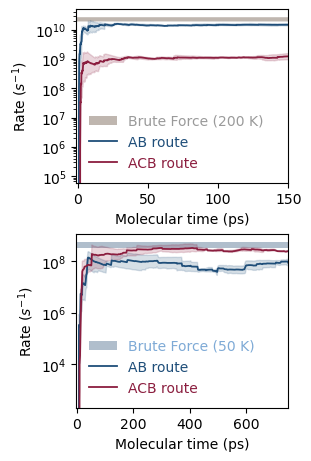

In [14]:
# ==========================
# FIXED CHANNEL COLORS
# ==========================

color_upper = "#8B1E3F"   # deep burgundy → Upper channel
color_lower = "#1F4E79"   # slate navy   → Lower channel


# fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=False)

fig, axes = plt.subplots(
    2, 1,
    figsize=(3.0, 4.5),
    # sharex=True,
    sharey=False,
    constrained_layout=True
)

# ============================================================
# LEFT PANEL — 200 K
# ============================================================
ax = axes[0]

ax.fill_between(
    (low_200[0][0][:2500] - 0.1) * 10000,
    1e12 * 0.018988199166707853,
    1e12 * 0.02648251150828471,
    color=color_bruteforce_200,
    alpha=0.9,
    edgecolor="none",
    label="Brute Force (200 K)"
)

# LOWER channel
t, m, lo, hi = mean_ci_from_replicas(
    low_200[0][0], [x[0] for x in low_200], [x[1] for x in low_200]
)
ax.plot(t*1000, m, color=color_lower, lw=1.3, label="AB route")
ax.fill_between(t*1000, lo, hi, color=color_lower, alpha=0.18)

# UPPER channel
t, m, lo, hi = mean_ci_from_replicas(
    high_200[0][0], [x[0] for x in high_200], [x[1] for x in high_200]
)
ax.plot(t*1000, m, color=color_upper, lw=1.3, label="ACB route")
ax.fill_between(t*1000, lo, hi, color=color_upper, alpha=0.18)

ax.set_xlim(-1, 150)
ax.set_xlabel("Molecular time (ps)")
ax.set_yscale("log")
leg = ax.legend(frameon=False)
print(c_bf)
legend_colors = [
     "#9A9A9A",         # Brute force band
    color_lower,  # AB route
    color_upper,  # ACB route
]

for txt, col in zip(leg.get_texts(), legend_colors):
    txt.set_color(col)


# ============================================================
# RIGHT PANEL — 50 K
# ============================================================
ax = axes[1]

ax.fill_between(
    [-10, 1200],
    1/(3.22e-9), 1/(1.86e-9),
    color=color_bruteforce_50,
    alpha=0.9,
    edgecolor="none",
    label="Brute Force (50 K)"
)

# LOWER channel
t, m, lo, hi = mean_ci_from_replicas(
    low_50[0][0], [x[0] for x in low_50], [x[1] for x in low_50]
)
ax.plot(t*1000, m, color=color_lower, lw=1.3, label="AB route")
ax.fill_between(t*1000, lo, hi, color=color_lower, alpha=0.18)

# UPPER channel
t, m, lo, hi = mean_ci_from_replicas(
    high_50[0][0], [x[0] for x in high_50], [x[1] for x in high_50]
)
ax.plot(t*1000, m, color=color_upper, lw=1.3, label="ACB route")
ax.fill_between(t*1000, lo, hi, color=color_upper, alpha=0.18)

ax.set_xlim(-1, 750)
ax.set_xlabel("Molecular time (ps)")
ax.set_yscale("log")
leg = ax.legend(frameon=False)
print(color_bruteforce_50)
legend_colors = [
    "#7EAAD6",         # Brute force band
    color_lower,  # AB route
    color_upper,  # ACB route
]

for txt, col in zip(leg.get_texts(), legend_colors):
    txt.set_color(col)

# ============================================================
# Shared formatting
# ============================================================
axes[0].set_ylabel(r"Rate ($s^{-1}$)")
axes[1].set_ylabel(r"Rate ($s^{-1}$)")

# plt.tight_layout()
plt.show()
